# Beyond GDP: Human Development and Capability Analysis

## Notebook 3 — Exploratory Data Analysis (EDA)

In this notebook we look at the data through charts. The goal is to see the shape
of each measure, how the measures relate to each other, and where the interesting
patterns are. Every chart is followed by a short, plain explanation of what it
shows.

## 1. Setup

We load the cleaned master dataset and set a clean, modern style for all charts:
a light background, a soft color palette, and a readable font size. Setting this
once keeps every chart in the notebook consistent.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

master_path = Path(r"D:\beyond-gdp-capability-analysis\data\processed\master_dataset.csv")
df = pd.read_csv(master_path)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Shape:", df.shape)
df.head(3)

Shape: (130, 18)


,country,code,hdi,life_expectancy,expected_schooling,mean_schooling,gni_per_capita,happiness_score,social_support_contrib,freedom_contrib,generosity_contrib,corruption_contrib,gdp_per_capita,health_expenditure,unemployment,inflation,population,cpi_score
0,Iceland,ISL,0.972,82.691,18.85059,13.908926,69116.93736,7.525,1.617,0.819,0.258,0.182,82138.789297,8.705101,3.518,8.736303,385663.0,77
1,Norway,NOR,0.970,83.308,18.79285,13.117962,112710.02110,7.302,1.517,0.835,0.224,0.484,87497.217965,9.429255,3.574,5.517850,5519601.0,81
2,Switzerland,CHE,0.970,83.954,16.66753,13.949121,81948.90177,7.060,1.425,0.759,0.173,0.498,100623.549627,11.690961,4.043,2.135401,8888822.0,80


## 2. How is HDI spread across countries?

A histogram groups countries into bins based on their HDI value and shows how many
countries fall in each bin. This tells us where most countries sit, and whether
they are bunched together or spread out.

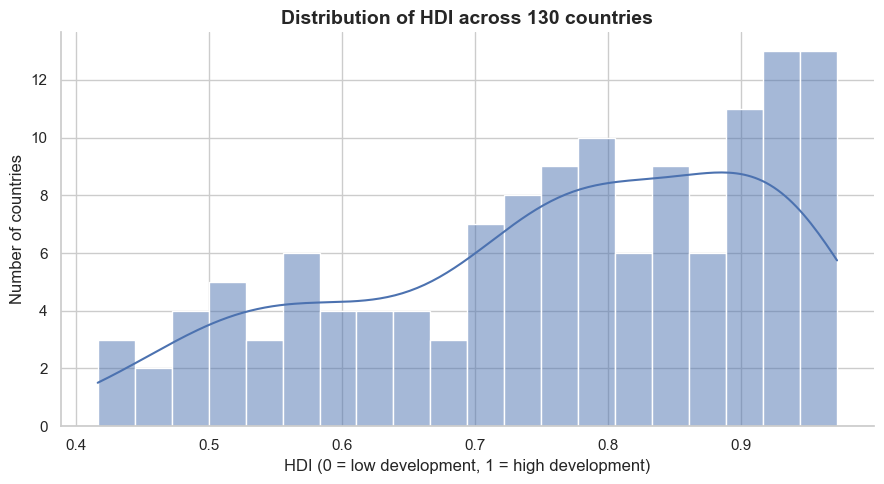

In [2]:
plt.figure()

sns.histplot(data=df, x="hdi", bins=20, kde=True, color="#4c72b0")

plt.title("Distribution of HDI across 130 countries")
plt.xlabel("HDI (0 = low development, 1 = high development)")
plt.ylabel("Number of countries")

plt.tight_layout()
plt.show()

**What this chart shows:**

Each bar is a group of countries with a similar HDI. The taller the bar, the more
countries sit at that HDI level.

Most countries are bunched on the right side, at high HDI values (roughly 0.7 and
above). Fewer countries sit on the left, at low HDI. So in our data, more countries
are at higher development levels, and only a small number are at the bottom.

The smooth line on top is just an easy way to see that overall shape: a big lump on
the high side, and a thin tail on the low side.

## 3. Does higher GDP mean higher HDI?

This is the central question. A scatter plot puts GDP per capita on one axis and
HDI on the other, with one dot per country. If money alone decided development, the
dots would form a clean straight upward line. We want to see how true that is.

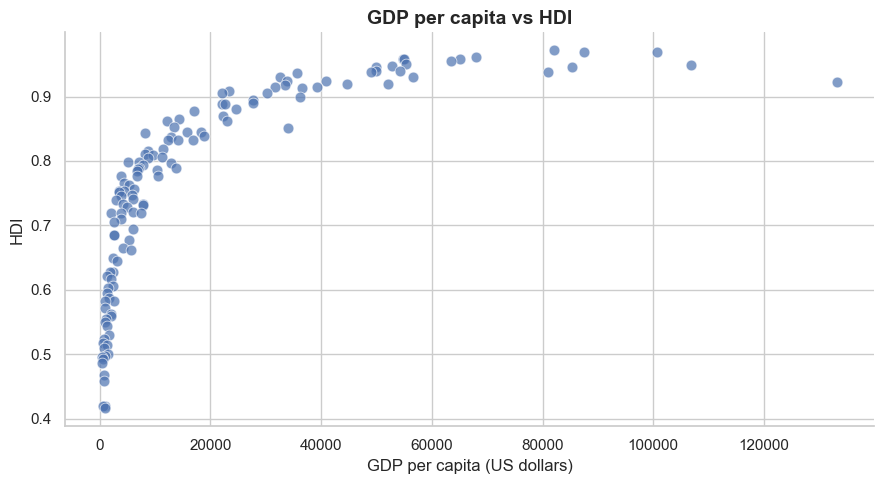

In [3]:
plt.figure()

sns.scatterplot(data=df, x="gdp_per_capita", y="hdi",
                color="#4c72b0", s=60, alpha=0.7)

plt.title("GDP per capita vs HDI")
plt.xlabel("GDP per capita (US dollars)")
plt.ylabel("HDI")

plt.tight_layout()
plt.show()

We add country labels for a few notable cases: the richest, the highest HDI, and a
few that stand out from the curve. Labelling only a handful keeps the chart readable
while still telling the story.

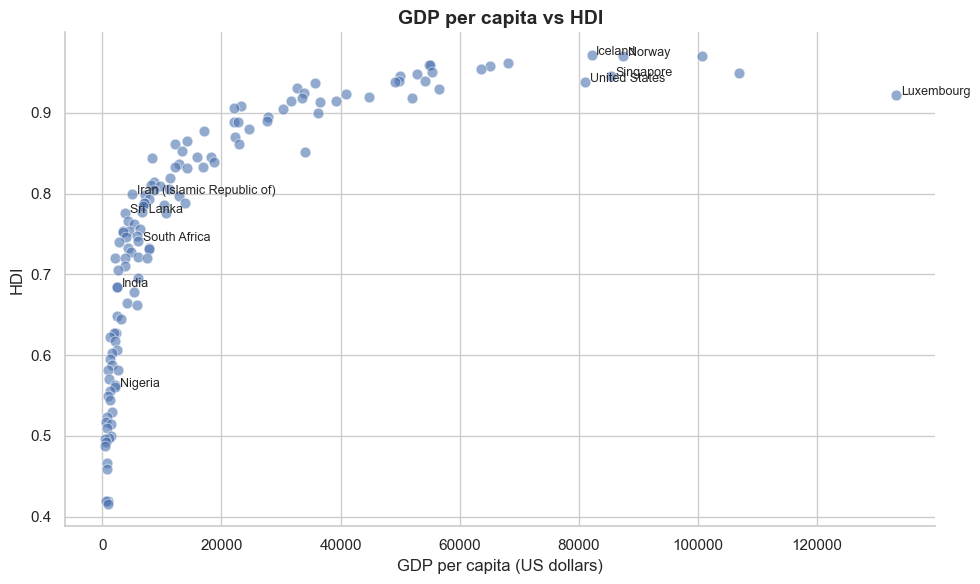

In [4]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="gdp_per_capita", y="hdi",
                color="#4c72b0", s=60, alpha=0.6)

label_countries = ["Luxembourg", "Norway", "United States", "Iceland",
                   "Qatar", "Singapore", "Iran (Islamic Republic of)",
                   "Sri Lanka", "South Africa", "India", "Nigeria"]

for _, row in df[df["country"].isin(label_countries)].iterrows():
    plt.text(row["gdp_per_capita"] + 800, row["hdi"], row["country"],
             fontsize=9)

plt.title("GDP per capita vs HDI")
plt.xlabel("GDP per capita (US dollars)")
plt.ylabel("HDI")

plt.tight_layout()
plt.show()

**What this chart shows:**

Each dot is a country. Left to right is GDP per capita (money). Bottom to top is HDI
(development).

The shape is the key. On the left side, where countries are poor, the dots climb up
very fast, even a small rise in income comes with a big jump in HDI. But on the
right side, where countries are already rich, the dots flatten out. After a point,
adding more money barely raises HDI.

In plain words: money matters a lot when a country is poor, but once basic needs are
met, extra income does little for development. That is why countries like Iran and
Sri Lanka sit higher than their income would suggest, while very rich countries are
all bunched near the top with little difference between them.

This single chart is the heart of the project: GDP and HDI are linked, but the link
is not a straight line, and money alone does not keep pushing development up.

## 4. Which measures move together?

A correlation heatmap shows, for every pair of measures, how strongly they move
together. Values run from -1 to +1. Close to +1 means they rise together, close to
-1 means one rises as the other falls, and near 0 means little relationship. The
colors make the strong pairs easy to spot at a glance.

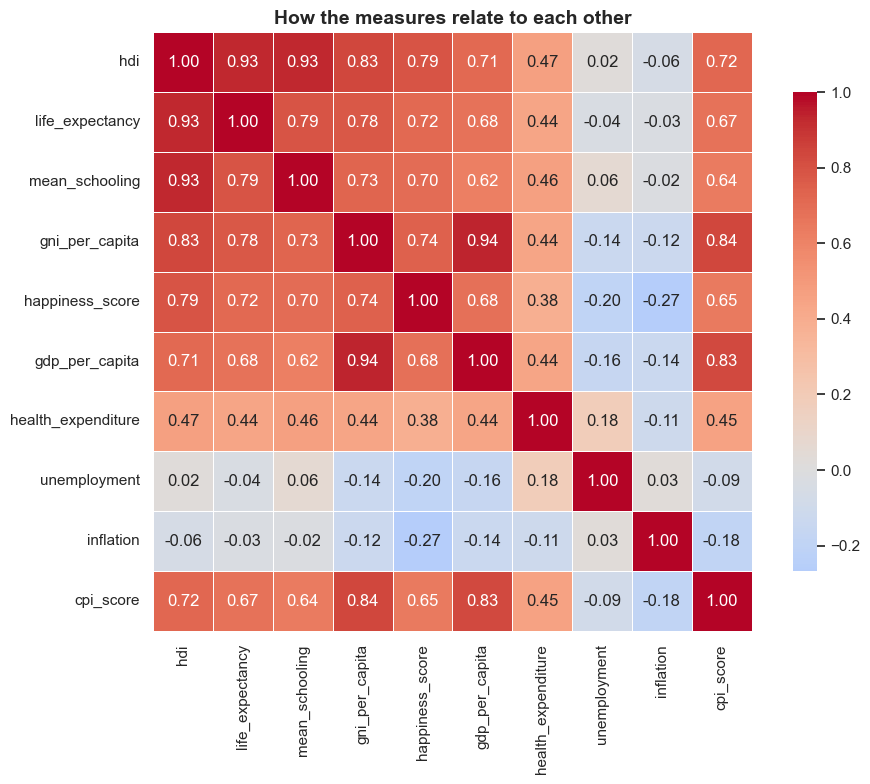

In [5]:
plt.figure(figsize=(10, 8))

num_cols = ["hdi", "life_expectancy", "mean_schooling", "gni_per_capita",
            "happiness_score", "gdp_per_capita", "health_expenditure",
            "unemployment", "inflation", "cpi_score"]

corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title("How the measures relate to each other")
plt.tight_layout()
plt.show()

**What this chart shows:**

Each box is how strongly two measures move together. Numbers run from -1 to +1. Near
+1 (deep red) means they rise together. Near 0 (pale) means almost no link. Below 0
(blue) means one goes up as the other goes down.

The strong, expected pairs:
- HDI moves almost perfectly with life expectancy (0.93) and schooling (0.93). That
  makes sense, because HDI is partly built from those.
- GDP per capita and GNI move together (0.94), they are two ways of measuring income.
- Corruption score (CPI) is high with income (0.84) and HDI (0.72): richer, more
  developed countries are seen as cleaner.

The interesting weak ones:
- HDI and GDP have a correlation of 0.71. Strong, but clearly not perfect. If money
  alone decided development, this would be much closer to 1. The gap is the room
  where health, education and governance matter.
- Happiness links more with HDI (0.79) than with GDP (0.68). So overall development
  explains happiness slightly better than raw income does.
- Unemployment and inflation barely connect with anything (values near 0). In this
  data, they do not explain development or happiness much.

In plain words: income is one strong piece of the picture, but development and
happiness are tied to more than just money, which is exactly the project's point.

## 5. How does happiness vary within each development group?

We split countries into four HDI groups and draw a boxplot of happiness for each.
A boxplot shows the middle value (the line inside the box), the range where most
countries fall (the box), and any unusual cases (dots outside the whiskers). This
tells us not just the average, but how spread out happiness is inside each group.

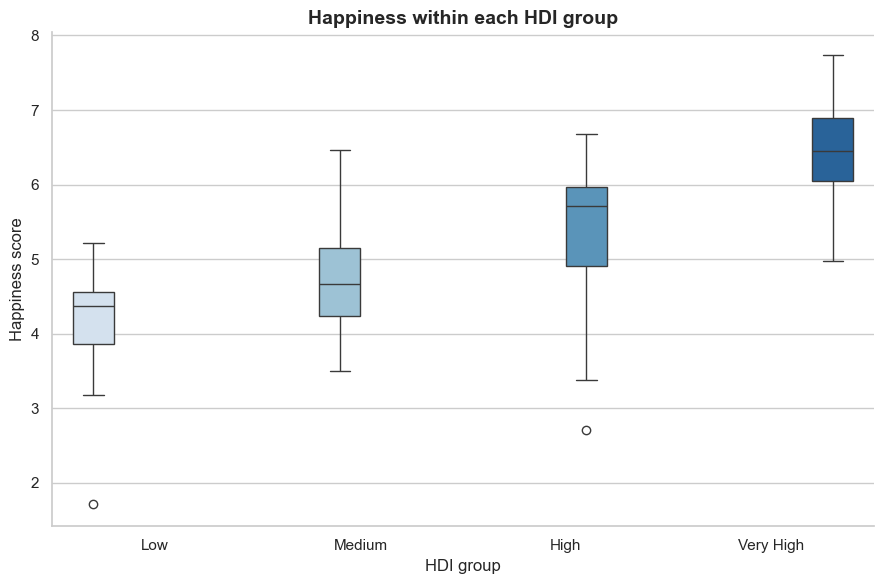

In [6]:
df["hdi_group"] = pd.cut(
    df["hdi"],
    bins=[0, 0.550, 0.700, 0.800, 1.0],
    labels=["Low", "Medium", "High", "Very High"]
)

plt.figure(figsize=(9, 6))

sns.boxplot(data=df, x="hdi_group", y="happiness_score",
            palette="Blues", hue="hdi_group", legend=False)

plt.title("Happiness within each HDI group")
plt.xlabel("HDI group")
plt.ylabel("Happiness score")

plt.tight_layout()
plt.show()

In [7]:
print(df["hdi_group"].value_counts(dropna=False))
print()
print("Max HDI:", df["hdi"].max())
print("Min HDI:", df["hdi"].min())

hdi_group
Very High    59
High         32
Medium       22
Low          17
Name: count, dtype: int64

Max HDI: 0.972
Min HDI: 0.416


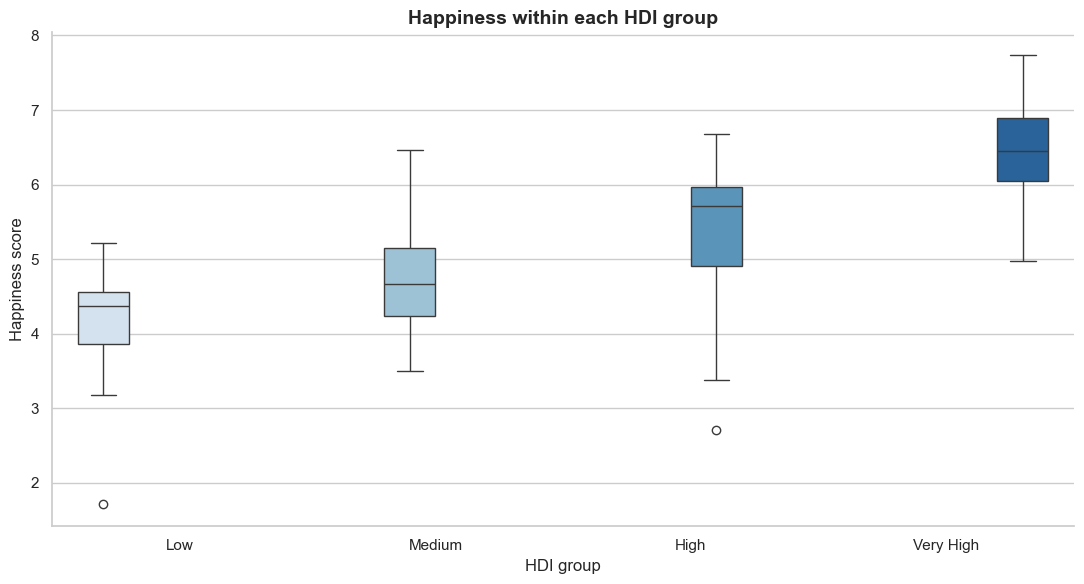

In [8]:
plt.figure(figsize=(11, 6))

sns.boxplot(data=df, x="hdi_group", y="happiness_score",
            order=["Low", "Medium", "High", "Very High"],
            palette="Blues", hue="hdi_group", legend=False)

plt.title("Happiness within each HDI group")
plt.xlabel("HDI group")
plt.ylabel("Happiness score")

plt.tight_layout()
plt.show()

**What this chart shows:**

First, how to read a box. For each HDI group:
- The line inside the box is the middle country, half are above it, half below.
- The box covers the bulk of the countries in that group.
- The thin lines (whiskers) reach out to the rest.
- A lone dot is an unusual country that sits far from its group.

Now the pattern. Going from Low to Very High, the boxes step upward. So more
developed groups are happier on average. That part is expected.

But look at how tall the boxes and whiskers are. Within a single group, happiness
still varies a lot, there is no single happiness value for "developed" or
"undeveloped" countries. Some countries in a lower group are happier than some in a
higher group, because the boxes overlap.

In plain words: development lifts happiness overall, but it does not fix it. Two
countries at the same development level can be quite far apart in happiness, which
means money and development are only part of what makes people happy.

## 6. Which countries are seen as the least corrupt?

A bar chart is the easiest way to compare countries side by side. Here we show the
15 countries with the highest CPI score. Remember the CPI scale: higher means
cleaner (less corruption), lower means more corruption. So these are the cleanest
countries in our data.

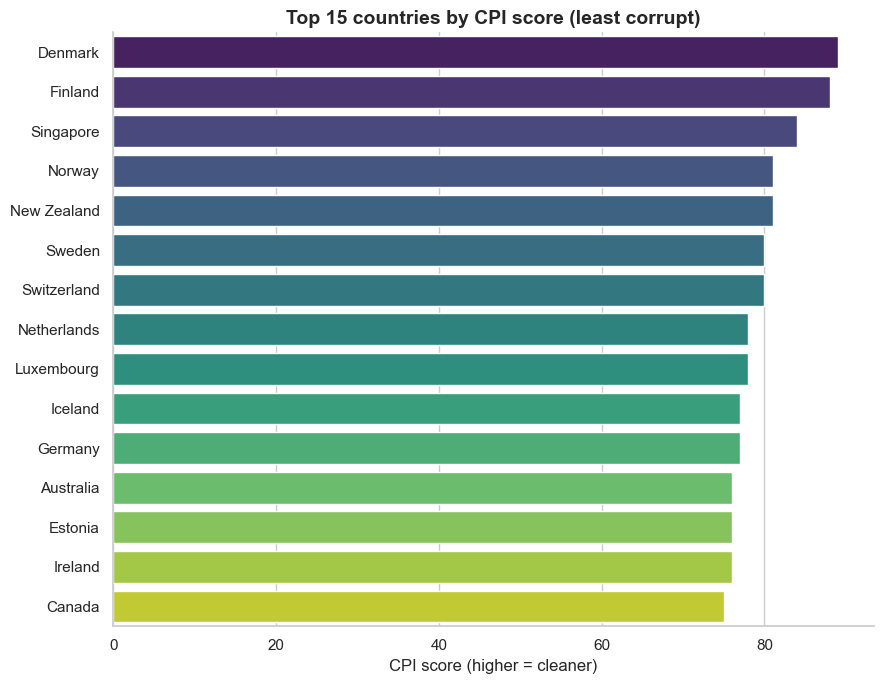

In [9]:
top_cpi = df.sort_values("cpi_score", ascending=False).head(15)

plt.figure(figsize=(9, 7))

sns.barplot(data=top_cpi, x="cpi_score", y="country",
            palette="viridis", hue="country", legend=False)

plt.title("Top 15 countries by CPI score (least corrupt)")
plt.xlabel("CPI score (higher = cleaner)")
plt.ylabel("")

plt.tight_layout()
plt.show()

**What this chart shows:**

Each bar is a country, and the longer the bar, the higher its CPI score, that is,
the less corruption it is seen to have.

Denmark, Finland and Singapore sit at the top as the cleanest in our data, followed
by Norway, New Zealand and the Nordic and Western European countries. Almost every
country here is also high on HDI and happiness.

This connects back to the heatmap: clean governance, high development and happiness
tend to show up in the same countries. Good institutions are part of the same story
as health, education and well-being, not a separate one.

## 7. Do cleaner countries have happier people?

This scatter plot puts the CPI score (cleanliness) on one axis and happiness on the
other, one dot per country. If less corruption goes with more happiness, the dots
should trend upward from left to right.

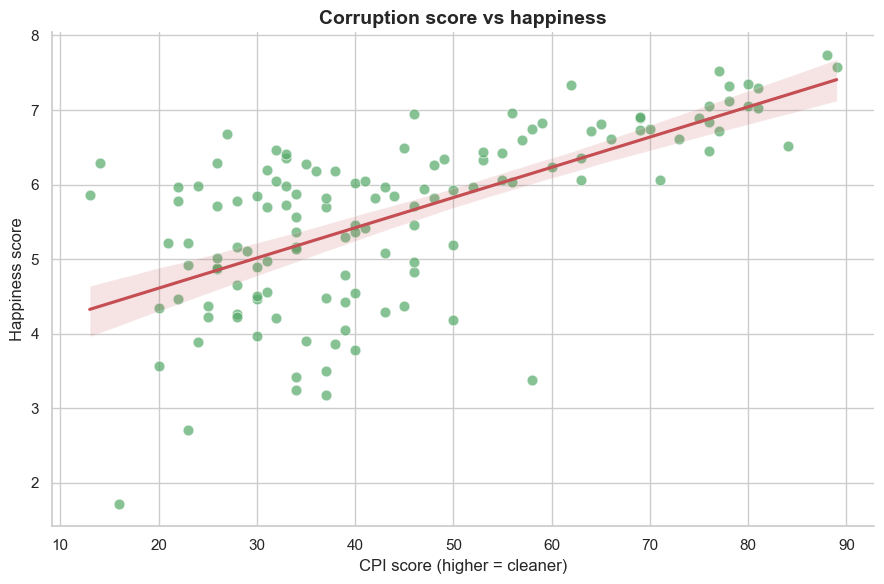

In [10]:
plt.figure(figsize=(9, 6))

sns.scatterplot(data=df, x="cpi_score", y="happiness_score",
                color="#55a868", s=60, alpha=0.7)

sns.regplot(data=df, x="cpi_score", y="happiness_score",
            scatter=False, color="#c44e52")

plt.title("Corruption score vs happiness")
plt.xlabel("CPI score (higher = cleaner)")
plt.ylabel("Happiness score")

plt.tight_layout()
plt.show()

**What this chart shows:**

Each dot is a country. Left to right is the CPI score (cleaner governance as you go
right). Bottom to top is happiness. The red line is the overall trend.

The line slopes upward, so cleaner countries do tend to have happier people. That
fits the heatmap, where CPI and happiness were positively linked.

But notice how scattered the dots are around the line. Plenty of countries sit well
above or below it. So less corruption goes with more happiness in general, but it is
a loose pattern, not a strict rule. Some fairly clean countries are not very happy,
and some less clean ones are happier than expected.

In plain words: good governance helps, but it is one ingredient among many. By
itself it does not decide how happy a country is, which again supports the project's
main idea that no single factor explains well-being.